<a href="https://colab.research.google.com/github/debchi108/Deep_learning/blob/main/Deep_learning_hand_in_assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercise 1:

Setup and import


In [1]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib
import matplotlib.pyplot as plt


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Plotting function (HA1 style)

In [3]:
# Cell 2: Plot learning curves (cost + accuracy) like HA1/HA2
def training_curve_plot(title, train_costs, test_costs, train_accuracy,
                        test_accuracy, batch_size, learning_rate, num_epochs,
                        elapsed, save_path=None):
    lg, md, sm = 18, 13, 9
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, y=1.15, fontsize=lg)

    elapsed_min, elapsed_sec = divmod(elapsed, 60)
    sub = (f'| Batch size: {batch_size} | Learning rate: {learning_rate} | '
           f'Epochs: {num_epochs} | Training time: {elapsed_min:.0f} min {elapsed_sec:.1f} sec |')
    fig.text(0.5, 0.99, sub, ha='center', fontsize=md)

    x = np.arange(1, len(train_costs) + 1)

    # Cost plot
    axs[0].plot(x, train_costs, label=f'Final train cost: {train_costs[-1]:.4f}')
    axs[0].plot(x, test_costs,  label=f'Final test cost: {test_costs[-1]:.4f}')
    axs[0].set_title('Costs', fontsize=md)
    axs[0].set_xlabel('Epochs', fontsize=md)
    axs[0].set_ylabel('Cost', fontsize=md)
    axs[0].legend(fontsize=sm)
    axs[0].tick_params(axis='both', labelsize=sm)

    # Accuracy plot
    axs[1].plot(x, train_accuracy, label=f'Final train acc: {100*train_accuracy[-1]:.2f}%')
    axs[1].plot(x, test_accuracy,  label=f'Final test acc: {100*test_accuracy[-1]:.2f}%')
    axs[1].set_title('Accuracy', fontsize=md)
    axs[1].set_xlabel('Epochs', fontsize=md)
    axs[1].set_ylabel('Accuracy', fontsize=md)
    axs[1].legend(fontsize=sm)
    axs[1].tick_params(axis='both', labelsize=sm)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print("Plot saved ->", save_path)
    plt.show()

Data loaders (MNIST)

In [4]:
# Cell 3: Load MNIST and create data loaders
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # standard MNIST normalization
])

train_set = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 474kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.62MB/s]


Cell 4: Model definition (Exercise 1 MLP)

In [5]:
# Cell 4: Fully-connected network (HA1 architecture)
class FullyConnectedNet(nn.Module):
    # [784 -> 128 -> 64 -> 10] with ReLU
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)     # flatten images
        x = F.relu(self.fc1(x))       # hidden layer 1
        x = F.relu(self.fc2(x))       # hidden layer 2
        return self.fc3(x)            # logits (no softmax here)

Cell 5: Reusable train/eval functions (this is what makes Exercises 2–5 easy)

In [6]:
# Cell 5: Training and evaluation functions (reusable for all exercises)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for X, y in loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(X)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)  # sum over samples
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def train_model(model, train_loader, test_loader, optimizer, criterion, num_epochs, print_every=10):
    model.to(device)

    train_costs, test_costs = [], []
    train_accs, test_accs = [], []

    t0 = time.time()

    for epoch in range(1, num_epochs + 1):
        model.train()

        batch_losses = []
        correct = 0
        total = 0

        for X, y in train_loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

            optimizer.zero_grad()          # clear old gradients
            logits = model(X)              # forward pass
            loss = criterion(logits, y)    # compute loss
            loss.backward()                # backprop
            optimizer.step()               # update weights

            batch_losses.append(loss.item())
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

        # epoch averages
        train_costs.append(float(np.mean(batch_losses)))
        train_accs.append(correct / total)

        # test metrics
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        test_costs.append(test_loss)
        test_accs.append(test_acc)

        if epoch == 1 or epoch % print_every == 0:
            print(f"Epoch {epoch:3d} | "
                  f"Train cost: {train_costs[-1]:.4f}, acc: {train_accs[-1]*100:.2f}% | "
                  f"Test cost: {test_costs[-1]:.4f}, acc: {test_accs[-1]*100:.2f}%")

    elapsed = time.time() - t0
    return train_costs, test_costs, train_accs, test_accs, elapsed

Cell 6: Run Exercise 1


Training Exercise 1 MLP...

Epoch   1 | Train cost: 0.4037, acc: 88.16% | Test cost: 0.1944, acc: 94.20%
Epoch  10 | Train cost: 0.0247, acc: 99.28% | Test cost: 0.0732, acc: 97.78%
Epoch  20 | Train cost: 0.0030, acc: 99.98% | Test cost: 0.0799, acc: 98.05%
Epoch  30 | Train cost: 0.0010, acc: 100.00% | Test cost: 0.0853, acc: 98.12%
Epoch  40 | Train cost: 0.0006, acc: 100.00% | Test cost: 0.0905, acc: 98.07%
Epoch  50 | Train cost: 0.0004, acc: 100.00% | Test cost: 0.0946, acc: 98.08%
Epoch  60 | Train cost: 0.0003, acc: 100.00% | Test cost: 0.0974, acc: 98.07%
Epoch  70 | Train cost: 0.0002, acc: 100.00% | Test cost: 0.0994, acc: 98.10%
Epoch  80 | Train cost: 0.0002, acc: 100.00% | Test cost: 0.1015, acc: 98.07%
Epoch  90 | Train cost: 0.0002, acc: 100.00% | Test cost: 0.1032, acc: 98.08%
Epoch 100 | Train cost: 0.0001, acc: 100.00% | Test cost: 0.1049, acc: 98.07%

Done! Training took 25.4 min
Final test accuracy:  98.07%
Final train accuracy: 100.00%
Plot saved -> ex1_fc_pytorc

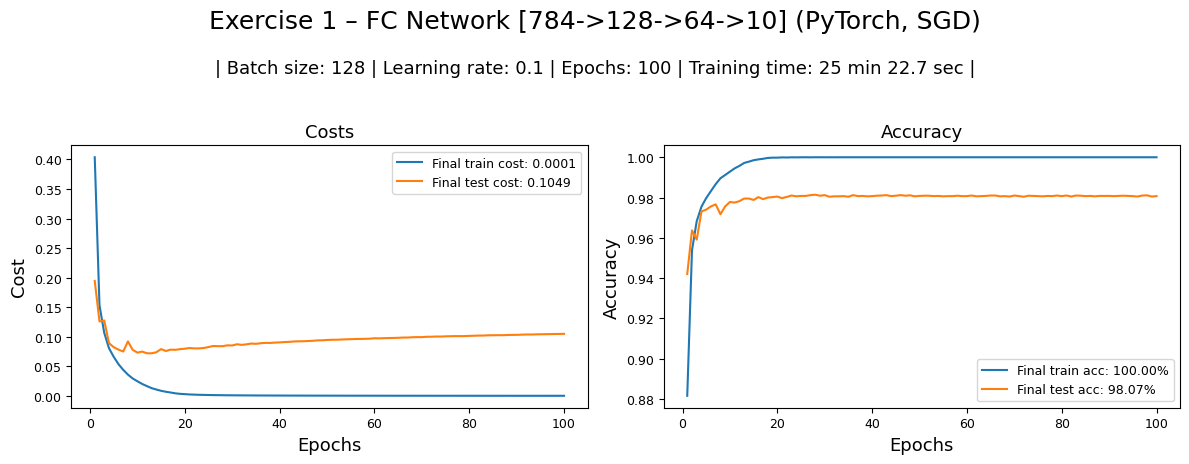

In [7]:
# Cell 6: Run Exercise 1 training

learning_rate = 0.1
num_epochs = 100

net = FullyConnectedNet()
criterion = nn.CrossEntropyLoss()                 # uses logits
optimizer = optim.SGD(net.parameters(), lr=learning_rate)

print("\nTraining Exercise 1 MLP...\n")
train_costs, test_costs, train_accs, test_accs, elapsed = train_model(
    net, train_loader, test_loader,
    optimizer, criterion,
    num_epochs=num_epochs,
    print_every=10
)

print(f"\nDone! Training took {elapsed/60:.1f} min")
print(f"Final test accuracy:  {test_accs[-1]*100:.2f}%")
print(f"Final train accuracy: {train_accs[-1]*100:.2f}%")

training_curve_plot(
    title="Exercise 1 – FC Network [784->128->64->10] (PyTorch, SGD)",
    train_costs=train_costs,
    test_costs=test_costs,
    train_accuracy=train_accs,
    test_accuracy=test_accs,
    batch_size=batch_size,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    elapsed=elapsed,
    save_path="ex1_fc_pytorch.png"
)

 CNN Architecture (Exactly as specified)

Conv 8 filters (3×3, stride 1, padding 1)

ReLU

MaxPool 2×2

Conv 16 filters

ReLU

MaxPool 2×2

Conv 32 filters

ReLU

Flatten

Fully connected → 10 outputs

In [9]:
# Exercise 2: CNN architecture (exact specification)

class CNN_SGD(nn.Module):
    def __init__(self):
        super().__init__()

        # 1) 8 filters, 3x3x1, stride=1, padding=1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8,
                               kernel_size=3, stride=1, padding=1)

        # 4) 16 filters, 3x3x8
        self.conv2 = nn.Conv2d(8, 16,
                               kernel_size=3, stride=1, padding=1)

        # 7) 32 filters, 3x3x16
        self.conv3 = nn.Conv2d(16, 32,
                               kernel_size=3, stride=1, padding=1)

        # After two 2x2 poolings:
        # 28x28 → 14x14 → 7x7
        # So final feature map: 32 x 7 x 7
        self.fc = nn.Linear(32 * 7 * 7, 10)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))  # conv1 + relu + pool
        x = self.pool(F.relu(self.conv2(x)))  # conv2 + relu + pool
        x = F.relu(self.conv3(x))             # conv3 + relu

        x = x.view(x.size(0), -1)             # flatten
        x = self.fc(x)                        # logits

        return x

Parameter Count (Layer-by-layer)

In [10]:
def count_parameters(model):
    print("Layer-wise parameter count:\n")
    total = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            n = param.numel()
            print(f"{name:20s} {n}")
            total += n
    print("\nTotal parameters:", total)
    return total

cnn_model = CNN_SGD()
total_params = count_parameters(cnn_model)

Layer-wise parameter count:

conv1.weight         72
conv1.bias           8
conv2.weight         1152
conv2.bias           16
conv3.weight         4608
conv3.bias           32
fc.weight            15680
fc.bias              10

Total parameters: 21578


rain CNN with SGD

Recommended settings:

LR = 0.01

Epochs = 15–20

Should reach >98% easily

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = CNN_SGD().to(device)

batch_size = 128
learning_rate = 0.01
EPOCHS = 20

optimizer = optim.SGD(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

train_costs, test_costs = [], []
train_accs, test_accs = [], []   # ✅ fixed line

start = time.time()

for epoch in range(1, EPOCHS + 1):

    # ---- Train ----
    model.train()
    correct, total = 0, 0
    epoch_loss_sum = 0.0

    for X, y in train_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        epoch_loss_sum += loss.item() * y.size(0)               # sum loss over samples
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss = epoch_loss_sum / total
    train_acc = correct / total

    # ---- Test ----
    model.eval()
    test_correct, test_total = 0, 0
    test_loss_sum = 0.0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(X)
            loss = criterion(logits, y)

            test_loss_sum += loss.item() * y.size(0)
            test_correct += (logits.argmax(1) == y).sum().item()
            test_total += y.size(0)

    test_loss = test_loss_sum / test_total
    test_acc = test_correct / test_total

    # Save per-epoch lists (exactly what assignment wants)
    train_costs.append(train_loss)
    test_costs.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train: loss={train_loss:.4f}, acc={train_acc*100:.2f}% | "
          f"Test: loss={test_loss:.4f}, acc={test_acc*100:.2f}%")

elapsed = time.time() - start
print("\nTraining complete")
print(f"Final test accuracy: {test_accs[-1]*100:.2f}%")
print(f"Training time: {elapsed/60:.2f} minutes")

Device: cuda
Epoch 01/20 | Train: loss=1.0176, acc=70.41% | Test: loss=0.3289, acc=90.25%
Epoch 02/20 | Train: loss=0.2909, acc=91.36% | Test: loss=0.2179, acc=93.57%
Epoch 03/20 | Train: loss=0.2014, acc=94.05% | Test: loss=0.1671, acc=95.04%
Epoch 04/20 | Train: loss=0.1523, acc=95.47% | Test: loss=0.1263, acc=96.09%
Epoch 05/20 | Train: loss=0.1250, acc=96.33% | Test: loss=0.1011, acc=96.86%
Epoch 06/20 | Train: loss=0.1083, acc=96.75% | Test: loss=0.0886, acc=97.07%
Epoch 07/20 | Train: loss=0.0957, acc=97.10% | Test: loss=0.0753, acc=97.61%
Epoch 08/20 | Train: loss=0.0868, acc=97.35% | Test: loss=0.0759, acc=97.51%
Epoch 09/20 | Train: loss=0.0795, acc=97.51% | Test: loss=0.0669, acc=97.82%
Epoch 10/20 | Train: loss=0.0740, acc=97.73% | Test: loss=0.0636, acc=97.91%
Epoch 11/20 | Train: loss=0.0693, acc=97.86% | Test: loss=0.0584, acc=98.02%
Epoch 12/20 | Train: loss=0.0645, acc=97.97% | Test: loss=0.0543, acc=98.24%
Epoch 13/20 | Train: loss=0.0610, acc=98.12% | Test: loss=0.060

Learning curve plot:

Plot saved -> ex2_cnn_sgd.png


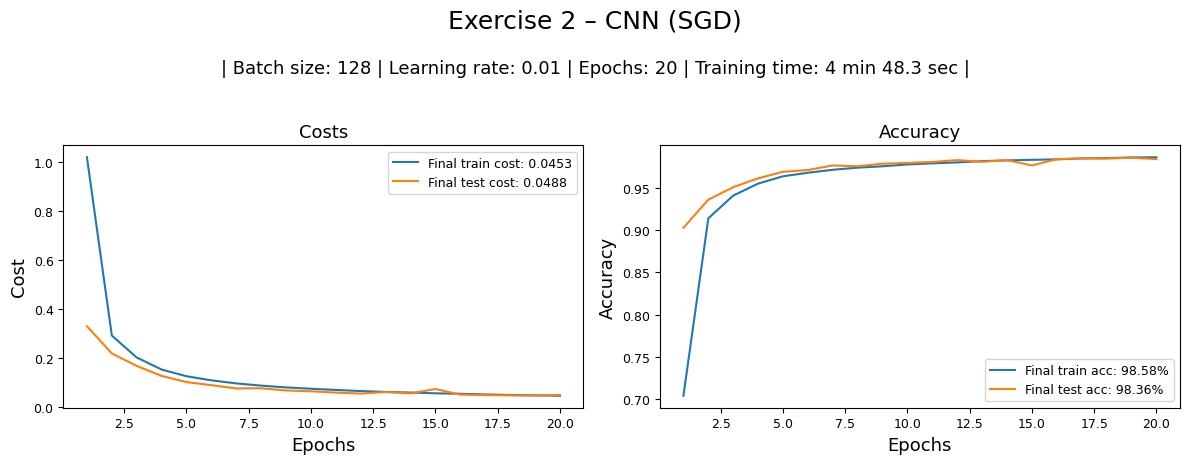

In [13]:
# Cell 5: Plot learning curves for Exercise 2

training_curve_plot(
    title="Exercise 2 – CNN (SGD)",
    train_costs=train_costs,
    test_costs=test_costs,
    train_accuracy=train_accs,
    test_accuracy=test_accs,
    batch_size=batch_size,
    learning_rate=learning_rate,
    num_epochs=EPOCHS,
    elapsed=elapsed,
    save_path="ex2_cnn_sgd.png"
)

Switch from SGD to ADAM for the CNN. Exercise 3.



In [14]:
# Hyperparameters (Adam defaults are fine; lr=0.001 is standard)
batch_size = 128
learning_rate = 0.001
EPOCHS = 20

model_adam = CNN_SGD().to(device)          # same architecture as Exercise 2
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_adam.parameters(), lr=learning_rate)

train_costs_adam, test_costs_adam = [], []
train_accs_adam, test_accs_adam = [], []

start = time.time()

for epoch in range(1, EPOCHS + 1):

    # ---- Train ----
    model_adam.train()
    correct, total = 0, 0
    epoch_loss_sum = 0.0

    for X, y in train_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model_adam(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        epoch_loss_sum += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss = epoch_loss_sum / total
    train_acc = correct / total

    # ---- Test ----
    model_adam.eval()
    test_correct, test_total = 0, 0
    test_loss_sum = 0.0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model_adam(X)
            loss = criterion(logits, y)

            test_loss_sum += loss.item() * y.size(0)
            test_correct += (logits.argmax(1) == y).sum().item()
            test_total += y.size(0)

    test_loss = test_loss_sum / test_total
    test_acc = test_correct / test_total

    # Save per-epoch lists (what assignment wants)
    train_costs_adam.append(train_loss)
    test_costs_adam.append(test_loss)
    train_accs_adam.append(train_acc)
    test_accs_adam.append(test_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train: loss={train_loss:.4f}, acc={train_acc*100:.2f}% | "
          f"Test: loss={test_loss:.4f}, acc={test_acc*100:.2f}%")

elapsed_adam = time.time() - start
print("\nTraining complete (Adam)")
print(f"Final test accuracy: {test_accs_adam[-1]*100:.2f}%")
print(f"Training time: {elapsed_adam/60:.2f} minutes")

Epoch 01/20 | Train: loss=0.3009, acc=91.05% | Test: loss=0.0838, acc=97.37%
Epoch 02/20 | Train: loss=0.0807, acc=97.52% | Test: loss=0.0561, acc=98.04%
Epoch 03/20 | Train: loss=0.0572, acc=98.21% | Test: loss=0.0434, acc=98.48%
Epoch 04/20 | Train: loss=0.0452, acc=98.58% | Test: loss=0.0394, acc=98.67%
Epoch 05/20 | Train: loss=0.0378, acc=98.82% | Test: loss=0.0379, acc=98.75%
Epoch 06/20 | Train: loss=0.0314, acc=99.01% | Test: loss=0.0356, acc=98.77%
Epoch 07/20 | Train: loss=0.0281, acc=99.15% | Test: loss=0.0328, acc=98.94%
Epoch 08/20 | Train: loss=0.0242, acc=99.21% | Test: loss=0.0357, acc=98.88%
Epoch 09/20 | Train: loss=0.0204, acc=99.32% | Test: loss=0.0326, acc=98.95%
Epoch 10/20 | Train: loss=0.0182, acc=99.43% | Test: loss=0.0311, acc=98.94%
Epoch 11/20 | Train: loss=0.0176, acc=99.39% | Test: loss=0.0325, acc=99.04%
Epoch 12/20 | Train: loss=0.0149, acc=99.51% | Test: loss=0.0363, acc=98.85%
Epoch 13/20 | Train: loss=0.0121, acc=99.59% | Test: loss=0.0388, acc=98.86%

Plot:

Plot saved -> ex3_cnn_adam.png


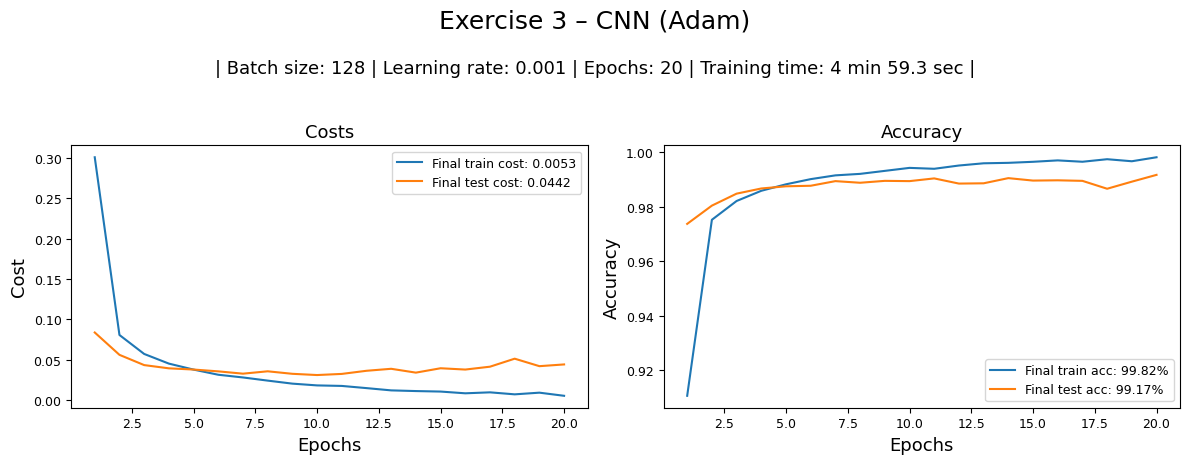

In [15]:
# Plot learning curves (Adam)

training_curve_plot(
    title="Exercise 3 – CNN (Adam)",
    train_costs=train_costs_adam,
    test_costs=test_costs_adam,
    train_accuracy=train_accs_adam,
    test_accuracy=test_accs_adam,
    batch_size=batch_size,
    learning_rate=learning_rate,
    num_epochs=EPOCHS,
    elapsed=elapsed_adam,
    save_path="ex3_cnn_adam.png"
)

RESIDUAL CONNECTION:

Instead of a layer just learning F(x), it learns F(x) + x. The input is added back to the output. This means even if the gradients get very small, the signal can still flow through the +x shortcut. This is what allows very deep networks to train without the gradients vanishing.

Instead of learning:

𝐻
(
𝑥
)
H(x)

The block learns:

𝐹
(
𝑥
)
=
𝐻
(
𝑥
)
−
𝑥
F(x)=H(x)−x

So:

𝐻
(
𝑥
)
=
𝐹
(
𝑥
)
+
𝑥
H(x)=F(x)+x

Residual Block + Residual CNN Model

In [18]:
class ResidualBlock(nn.Module):
    """
    A basic residual block:
    x → Conv → ReLU → Conv → + skip connection → ReLU

    If input and output channels differ,
    we use a 1x1 convolution to match dimensions.
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()

        # First convolution (changes channels if needed)
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Second convolution (keeps output channels)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1
        )

        # Projection layer (used only if channel size changes)
        self.proj = None
        if in_channels != out_channels:
            self.proj = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=1
            )

    def forward(self, x):

        identity = x  # store original input (skip path)

        out = F.relu(self.conv1(x))  # first conv + activation
        out = self.conv2(out)        # second conv (no activation yet)

        # If channels changed, project skip path
        if self.proj is not None:
            identity = self.proj(identity)

        # Add skip connection
        out = out + identity

        # Final activation
        out = F.relu(out)

        return out

Parameter count

In [19]:
# Cell 2: Parameter count for the residual model

res_model = CNN_Residual()
total_params_res = sum(p.numel() for p in res_model.parameters() if p.requires_grad)
print("Total trainable parameters (Residual CNN):", total_params_res)

for name, p in res_model.named_parameters():
    print(f"{name:25s} {p.numel()}")

Total trainable parameters (Residual CNN): 33834
conv1.weight              72
conv1.bias                8
block2.conv1.weight       1152
block2.conv1.bias         16
block2.conv2.weight       2304
block2.conv2.bias         16
block2.proj.weight        128
block2.proj.bias          16
block3.conv1.weight       4608
block3.conv1.bias         32
block3.conv2.weight       9216
block3.conv2.bias         32
block3.proj.weight        512
block3.proj.bias          32
fc.weight                 15680
fc.bias                   10


Residual CNN

In [20]:
# Residual CNN model
# Same overall structure as Exercise 3,
# but conv2 and conv3 replaced with residual blocks.

class CNN_Residual(nn.Module):

    def __init__(self):
        super().__init__()

        # First convolution (same as before)
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1)

        # Max pooling
        self.pool = nn.MaxPool2d(2, 2)

        # Replace conv2 with residual block
        self.block2 = ResidualBlock(8, 16)

        # Replace conv3 with residual block
        self.block3 = ResidualBlock(16, 32)

        # Fully connected output layer
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):

        # First conv + pool
        x = self.pool(F.relu(self.conv1(x)))  # (1,28,28) → (8,14,14)

        # Residual block + pool
        x = self.pool(self.block2(x))         # (8,14,14) → (16,7,7)

        # Second residual block
        x = self.block3(x)                   # (16,7,7) → (32,7,7)

        # Flatten for FC
        x = x.view(x.size(0), -1)

        # Final classification layer
        x = self.fc(x)

        return x

Train with Adam:

In [24]:
# Train residual CNN with Adam (fair comparison with Exercise 3)

import time
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

batch_size = 128
learning_rate = 0.001   # same as Exercise 3
EPOCHS = 20

model_res = CNN_Residual().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_res.parameters(), lr=learning_rate)

train_costs_res, test_costs_res = [], []
train_accs_res, test_accs_res = [], []

start = time.time()

for epoch in range(1, EPOCHS + 1):

    # ---- Training ----
    model_res.train()
    correct, total = 0, 0
    train_loss_sum = 0.0

    for X, y in train_loader:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model_res(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss = train_loss_sum / total
    train_acc = correct / total

    # ---- Evaluation ----
    model_res.eval()
    test_correct, test_total = 0, 0
    test_loss_sum = 0.0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            logits = model_res(X)
            loss = criterion(logits, y)

            test_loss_sum += loss.item() * y.size(0)
            test_correct += (logits.argmax(1) == y).sum().item()
            test_total += y.size(0)

    test_loss = test_loss_sum / test_total
    test_acc = test_correct / test_total

    train_costs_res.append(train_loss)
    test_costs_res.append(test_loss)
    train_accs_res.append(train_acc)
    test_accs_res.append(test_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train acc: {train_acc*100:.2f}% | "
          f"Test acc: {test_acc*100:.2f}%")

elapsed_res = time.time() - start

print("\nTraining complete (Residual + Adam)")
print(f"Final test accuracy: {test_accs_res[-1]*100:.2f}%")
print(f"Training time: {elapsed_res/60:.2f} minutes")

Device: cuda
Epoch 01/20 | Train acc: 92.26% | Test acc: 98.20%
Epoch 02/20 | Train acc: 98.17% | Test acc: 98.36%
Epoch 03/20 | Train acc: 98.70% | Test acc: 98.77%
Epoch 04/20 | Train acc: 98.97% | Test acc: 98.97%
Epoch 05/20 | Train acc: 99.15% | Test acc: 98.81%
Epoch 06/20 | Train acc: 99.30% | Test acc: 99.08%
Epoch 07/20 | Train acc: 99.40% | Test acc: 99.14%
Epoch 08/20 | Train acc: 99.44% | Test acc: 99.19%
Epoch 09/20 | Train acc: 99.51% | Test acc: 99.18%
Epoch 10/20 | Train acc: 99.54% | Test acc: 99.19%
Epoch 11/20 | Train acc: 99.66% | Test acc: 98.96%
Epoch 12/20 | Train acc: 99.63% | Test acc: 99.23%
Epoch 13/20 | Train acc: 99.68% | Test acc: 99.23%
Epoch 14/20 | Train acc: 99.74% | Test acc: 99.14%
Epoch 15/20 | Train acc: 99.77% | Test acc: 99.21%
Epoch 16/20 | Train acc: 99.75% | Test acc: 99.12%
Epoch 17/20 | Train acc: 99.80% | Test acc: 99.04%
Epoch 18/20 | Train acc: 99.80% | Test acc: 99.14%
Epoch 19/20 | Train acc: 99.76% | Test acc: 99.20%
Epoch 20/20 | Trai

Plot

Plot saved -> ex4_residual_adam.png


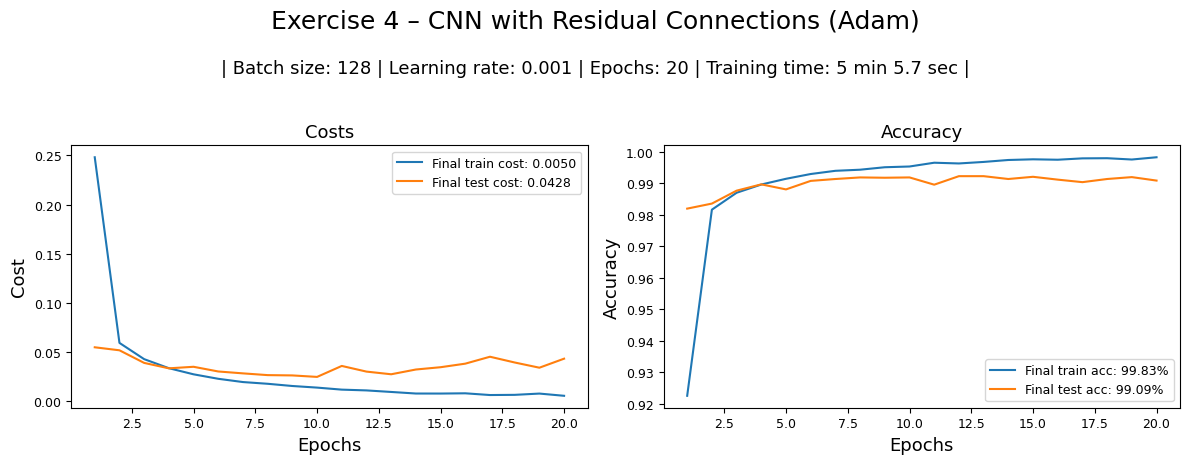

In [25]:
# Plot learning curves for Exercise 4 (Residual + Adam)

training_curve_plot(
    title="Exercise 4 – CNN with Residual Connections (Adam)",
    train_costs=train_costs_res,
    test_costs=test_costs_res,
    train_accuracy=train_accs_res,
    test_accuracy=test_accs_res,
    batch_size=batch_size,
    learning_rate=learning_rate,
    num_epochs=EPOCHS,
    elapsed=elapsed_res,
    save_path="ex4_residual_adam.png"
)

BatchNorm CNN + Dropout CNN

In [26]:
class CNN_BatchNorm(nn.Module):
    """
    Same CNN structure as before, but with BatchNorm after each conv.
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, stride=1, padding=1)
        self.bn1   = nn.BatchNorm2d(8)

        self.conv2 = nn.Conv2d(8, 16, 3, stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(16)

        self.conv3 = nn.Conv2d(16, 32, 3, stride=1, padding=1)
        self.bn3   = nn.BatchNorm2d(32)

        self.pool = nn.MaxPool2d(2, 2)
        self.fc   = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)


class CNN_Dropout(nn.Module):
    """
    Same CNN structure as before, but with Dropout.
    Dropout is usually applied after activations and/or before FC.
    """
    def __init__(self, p=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(16, 32, 3, stride=1, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p)          # dropout layer
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))

        x = x.view(x.size(0), -1)
        x = self.dropout(x)                   # dropout before FC
        return self.fc(x)

Training function

In [27]:
def train_model_generic(model, train_loader, test_loader, optimizer, criterion, epochs, device):
    train_costs, test_costs = [], []
    train_accs, test_accs = [], []

    start = time.time()
    model.to(device)

    for epoch in range(1, epochs + 1):

        # ---- Train ----
        model.train()
        correct, total = 0, 0
        loss_sum = 0.0

        for X, y in train_loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

        train_loss = loss_sum / total
        train_acc  = correct / total

        # ---- Test ----
        model.eval()
        correct_t, total_t = 0, 0
        loss_t_sum = 0.0

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
                logits = model(X)
                loss = criterion(logits, y)

                loss_t_sum += loss.item() * y.size(0)
                correct_t += (logits.argmax(1) == y).sum().item()
                total_t += y.size(0)

        test_loss = loss_t_sum / total_t
        test_acc  = correct_t / total_t

        train_costs.append(train_loss)
        test_costs.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(f"Epoch {epoch:02d}/{epochs} | Train acc: {train_acc*100:.2f}% | Test acc: {test_acc*100:.2f}%")

    elapsed = time.time() - start
    return train_costs, test_costs, train_accs, test_accs, elapsed

Train BatchNorm model

In [28]:
# Cell 3: Train CNN + BatchNorm (Adam)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 20
lr = 0.001
batch_size = 128

bn_model = CNN_BatchNorm()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=lr)

train_costs_bn, test_costs_bn, train_accs_bn, test_accs_bn, elapsed_bn = train_model_generic(
    bn_model, train_loader, test_loader, optimizer, criterion, epochs, device
)

print(f"\nBatchNorm final test acc: {test_accs_bn[-1]*100:.2f}% | time: {elapsed_bn/60:.2f} min")

Epoch 01/20 | Train acc: 95.58% | Test acc: 98.55%
Epoch 02/20 | Train acc: 98.45% | Test acc: 98.55%
Epoch 03/20 | Train acc: 98.95% | Test acc: 98.77%
Epoch 04/20 | Train acc: 99.14% | Test acc: 99.01%
Epoch 05/20 | Train acc: 99.28% | Test acc: 98.75%
Epoch 06/20 | Train acc: 99.39% | Test acc: 98.96%
Epoch 07/20 | Train acc: 99.45% | Test acc: 98.80%
Epoch 08/20 | Train acc: 99.56% | Test acc: 98.81%
Epoch 09/20 | Train acc: 99.64% | Test acc: 98.87%
Epoch 10/20 | Train acc: 99.68% | Test acc: 98.76%
Epoch 11/20 | Train acc: 99.71% | Test acc: 98.92%
Epoch 12/20 | Train acc: 99.74% | Test acc: 98.94%
Epoch 13/20 | Train acc: 99.81% | Test acc: 99.08%
Epoch 14/20 | Train acc: 99.73% | Test acc: 98.97%
Epoch 15/20 | Train acc: 99.77% | Test acc: 99.00%
Epoch 16/20 | Train acc: 99.80% | Test acc: 98.98%
Epoch 17/20 | Train acc: 99.84% | Test acc: 98.89%
Epoch 18/20 | Train acc: 99.92% | Test acc: 99.03%
Epoch 19/20 | Train acc: 99.84% | Test acc: 98.80%
Epoch 20/20 | Train acc: 99.78%

Plot BatchNorm curve

Plot saved -> ex5_batchnorm.png


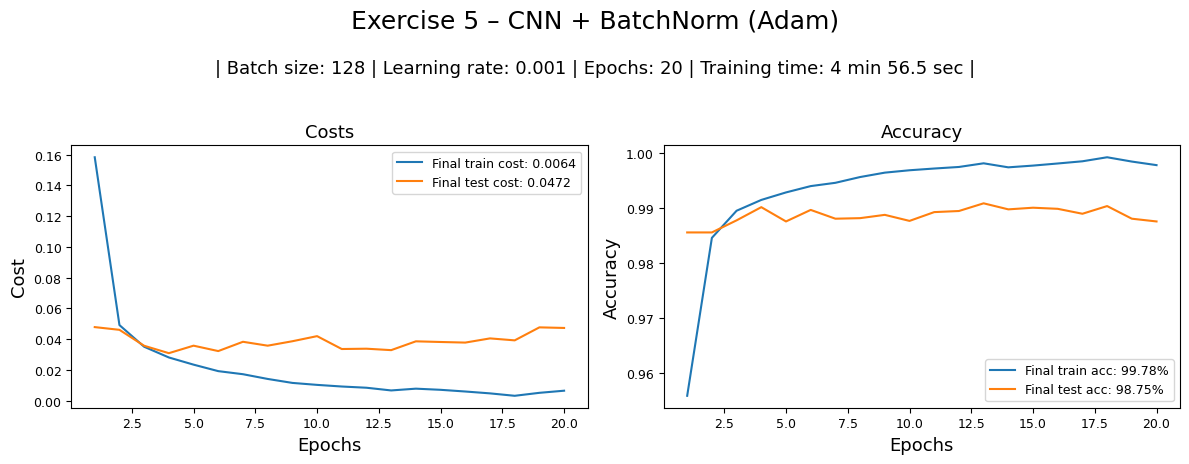

In [29]:
training_curve_plot(
    title="Exercise 5 – CNN + BatchNorm (Adam)",
    train_costs=train_costs_bn,
    test_costs=test_costs_bn,
    train_accuracy=train_accs_bn,
    test_accuracy=test_accs_bn,
    batch_size=batch_size,
    learning_rate=lr,
    num_epochs=epochs,
    elapsed=elapsed_bn,
    save_path="ex5_batchnorm.png"
)

Train Dropout model

In [30]:
# Cell 5: Train CNN + Dropout (Adam)

drop_model = CNN_Dropout(p=0.5)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(drop_model.parameters(), lr=lr)

train_costs_do, test_costs_do, train_accs_do, test_accs_do, elapsed_do = train_model_generic(
    drop_model, train_loader, test_loader, optimizer, criterion, epochs, device
)

print(f"\nDropout final test acc: {test_accs_do[-1]*100:.2f}% | time: {elapsed_do/60:.2f} min")

Epoch 01/20 | Train acc: 89.70% | Test acc: 97.75%
Epoch 02/20 | Train acc: 96.94% | Test acc: 98.42%
Epoch 03/20 | Train acc: 97.77% | Test acc: 98.62%
Epoch 04/20 | Train acc: 98.04% | Test acc: 98.72%
Epoch 05/20 | Train acc: 98.23% | Test acc: 98.93%
Epoch 06/20 | Train acc: 98.47% | Test acc: 99.04%
Epoch 07/20 | Train acc: 98.51% | Test acc: 98.99%
Epoch 08/20 | Train acc: 98.58% | Test acc: 99.05%
Epoch 09/20 | Train acc: 98.67% | Test acc: 99.13%
Epoch 10/20 | Train acc: 98.78% | Test acc: 98.98%
Epoch 11/20 | Train acc: 98.80% | Test acc: 99.12%
Epoch 12/20 | Train acc: 98.88% | Test acc: 99.17%
Epoch 13/20 | Train acc: 98.90% | Test acc: 99.22%
Epoch 14/20 | Train acc: 99.00% | Test acc: 99.22%
Epoch 15/20 | Train acc: 98.98% | Test acc: 99.19%
Epoch 16/20 | Train acc: 99.15% | Test acc: 99.28%
Epoch 17/20 | Train acc: 99.08% | Test acc: 99.25%
Epoch 18/20 | Train acc: 99.05% | Test acc: 99.24%
Epoch 19/20 | Train acc: 99.13% | Test acc: 99.17%
Epoch 20/20 | Train acc: 99.11%

Plot Dropout curve

Plot saved -> ex5_dropout.png


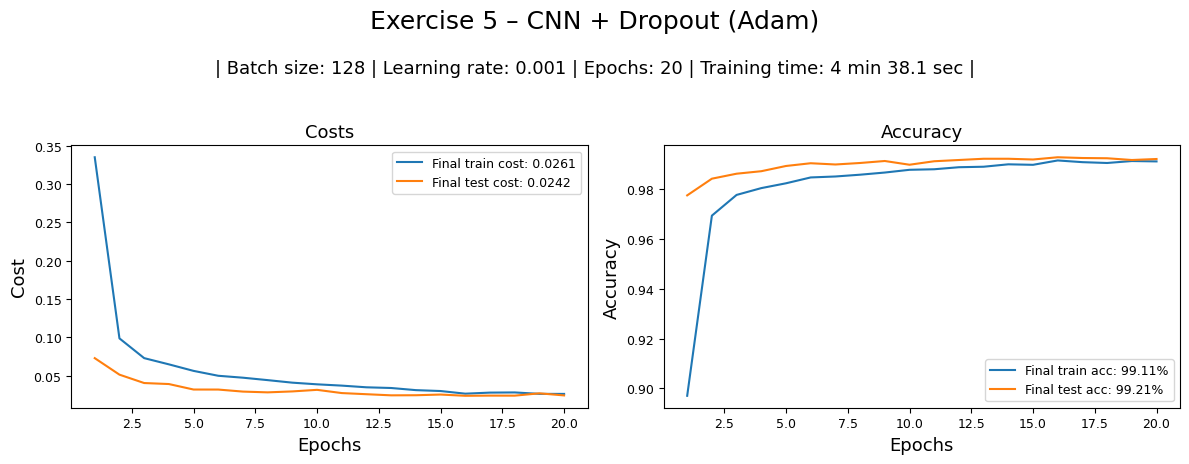

In [31]:
training_curve_plot(
    title="Exercise 5 – CNN + Dropout (Adam)",
    train_costs=train_costs_do,
    test_costs=test_costs_do,
    train_accuracy=train_accs_do,
    test_accuracy=test_accs_do,
    batch_size=batch_size,
    learning_rate=lr,
    num_epochs=epochs,
    elapsed=elapsed_do,
    save_path="ex5_dropout.png"
)

confusion matrix

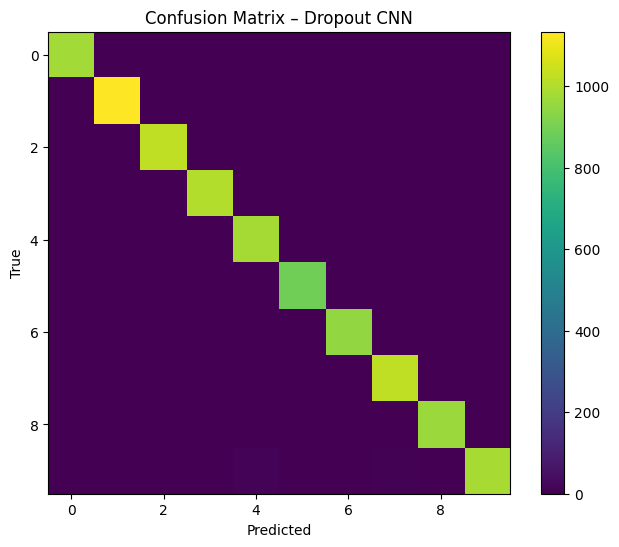

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

model = drop_model  # best model
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        preds = logits.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix – Dropout CNN")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

10 Misclassified Examples

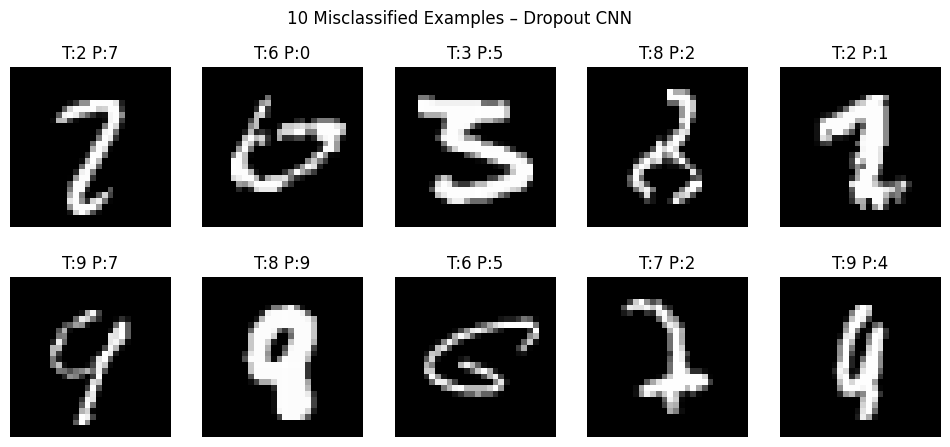

In [33]:
# Find misclassified examples
misclassified = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        preds = logits.argmax(1)

        for i in range(len(y)):
            if preds[i].cpu() != y[i]:
                misclassified.append((X[i].cpu(), y[i], preds[i].cpu()))
        if len(misclassified) >= 10:
            break

# Plot first 10
plt.figure(figsize=(12,5))
for i in range(10):
    img, true_label, pred_label = misclassified[i]
    plt.subplot(2,5,i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"T:{true_label} P:{pred_label}")
    plt.axis('off')

plt.suptitle("10 Misclassified Examples – Dropout CNN")
plt.show()